In [1]:
from scripts import indices, plot, validate

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from pathlib import Path

Set up of input data: random samples of surface reflectance across all 8 PS bands, labeled by land cover class (generated via QGIS model)

In [2]:
fp_bands = Path(r'C:\\Users\\remot\\Documents\\Jerome\\03_Independent_Research\\20260630 Mangrove and Seagrass Monitoring\\03_Data_management\\02_Processed_data\\Shapefiles\\Hinatuan-SurigaoDelSur_PS8BandsSamples-Corrected_LandCoverNAMRIA_20210729.csv')

df_bands = pd.read_csv(fp_bands).drop(columns=['id', 'xcoord', 'ycoord', 'gmw1'])
# df_bands['LCM_CLASS'] = df_bands['LCM_CLASS'].astype('category')

band_names = [col for col in df_bands.columns if col.startswith('b')]
df_bands = indices.remove_outliers(df_bands, band_names)

df_bands.head()

Number of outliers detected:  869


,LCM_CLASS,b1,b2,b3,b4,b5,b6,b7,b8
0,Annual Crop,155,321,504,525,553,465,1060,2996
1,Annual Crop,74,261,510,560,443,288,1120,4128
2,Annual Crop,127,295,536,597,561,437,1105,3452
3,Annual Crop,76,238,451,464,458,357,811,2773
4,Annual Crop,195,322,560,623,632,493,1150,4329


In [3]:
df_bands_melt = df_bands.melt(
    id_vars=['LCM_CLASS'],
    value_vars=band_names,
    var_name='band',
    value_name='sr'
)

df_bands_melt.head()

,LCM_CLASS,band,sr
0,Annual Crop,b1,155
1,Annual Crop,b1,74
2,Annual Crop,b1,127
3,Annual Crop,b1,76
4,Annual Crop,b1,195


Initial exploration: spectral signatures of vegetation classes

In [4]:
df_bands_melt['LCM_CLASS'].unique()

<ArrowStringArray>
[    'Annual Crop',    'Brush/Shrubs',        'Built-up', 'Mangrove Forest',
        'Fishpond',       'Grassland',    'Inland Water',     'Open Forest',
  'Perennial Crop']
Length: 9, dtype: str

In [5]:
vegetation_classes = [
    'Mangrove Forest', 
    'Perennial Crop', 
    # 'Annual Crop', 
    # 'Brush/Shrubs'
]

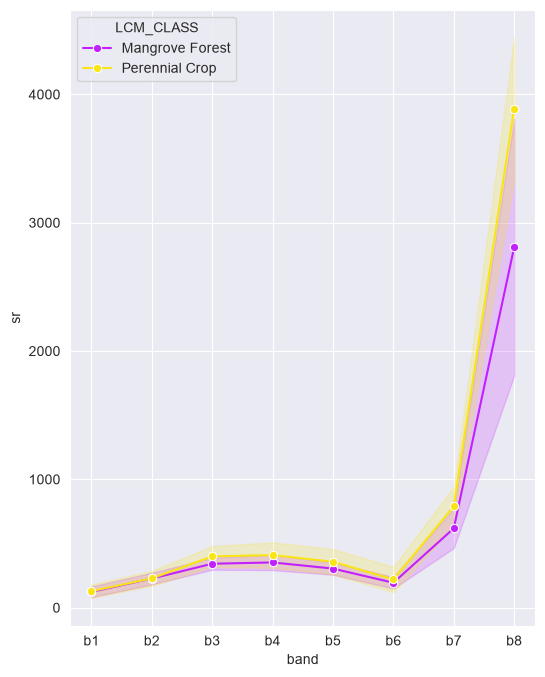

In [6]:
sns.set_style('darkgrid')
ax = plot.spectral_signature(
    data=df_bands_melt,
    category_column='LCM_CLASS',
    value_column='sr',
    band_column='band',
    cats_compared=vegetation_classes
)

ax.figure.set_size_inches(6, 8)

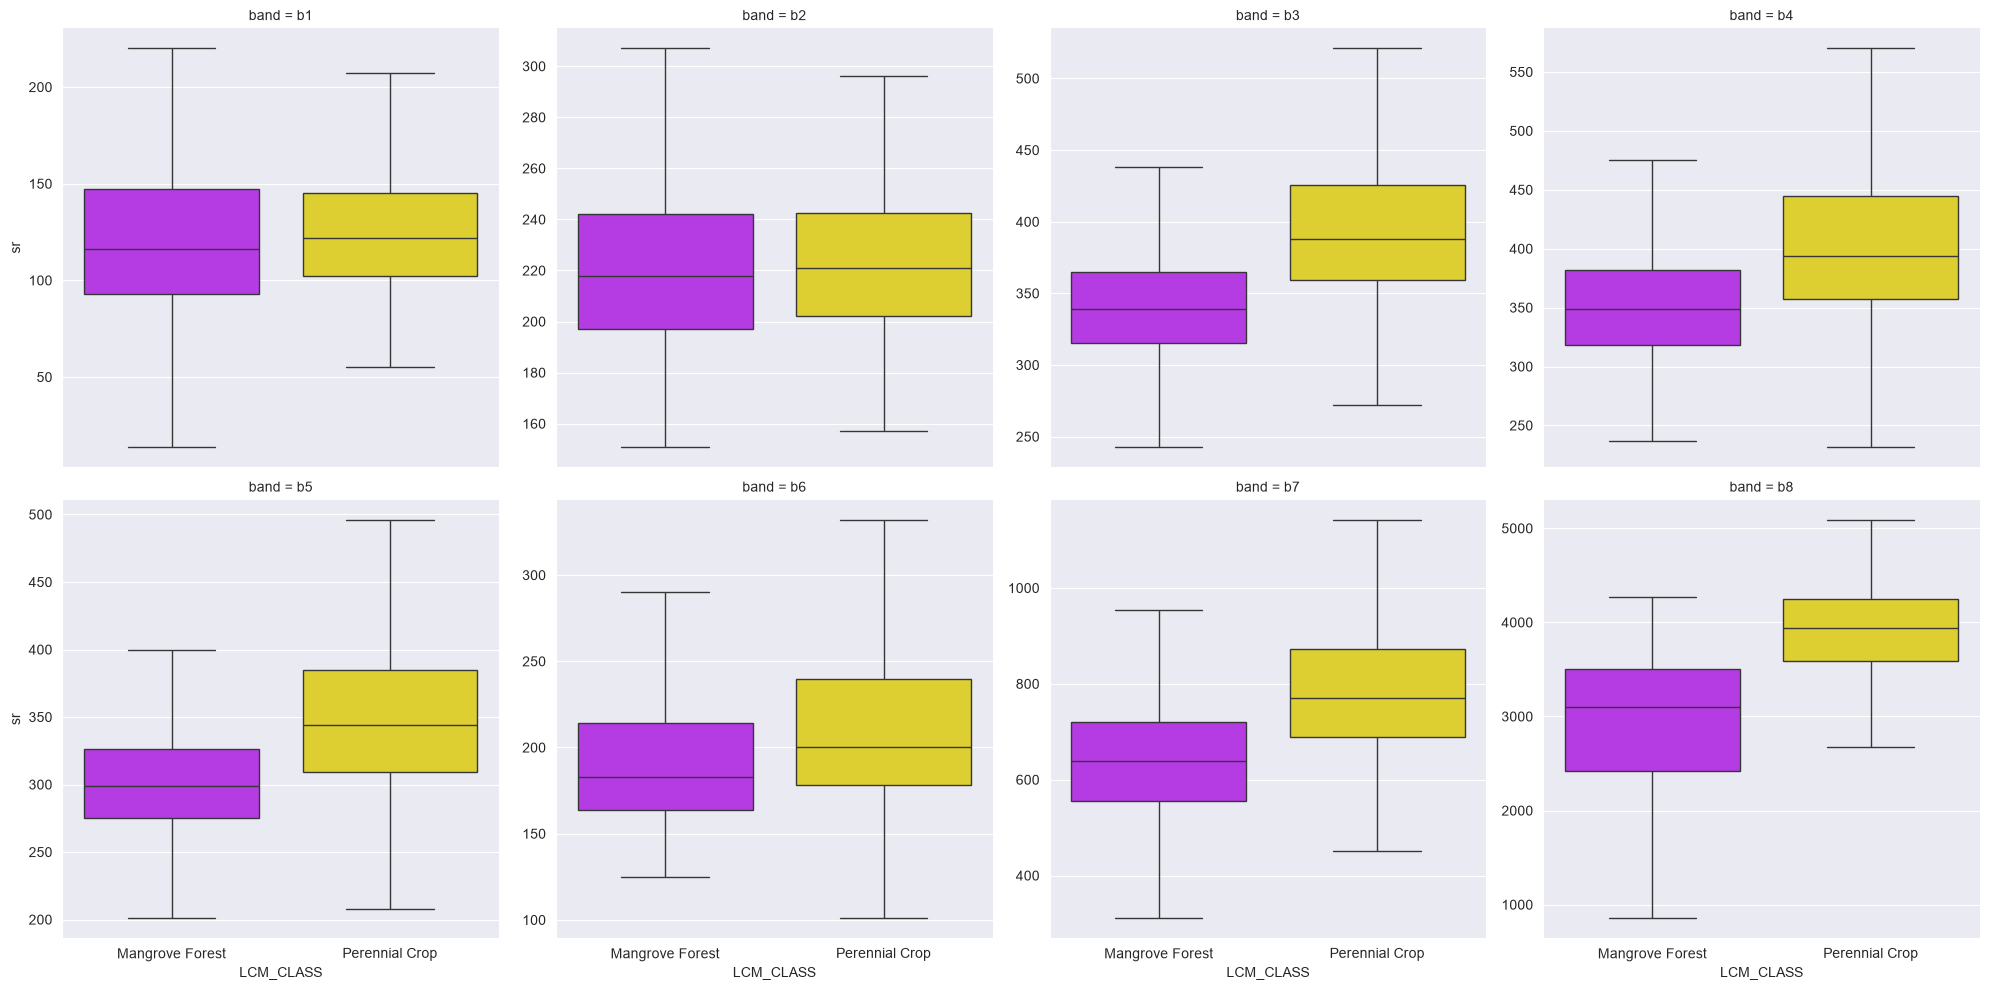

In [7]:
plot.boxplot_bands(
    data=df_bands_melt,
    category_column='LCM_CLASS',
    value_column='sr',
    band_column='band',
    cats_compared=vegetation_classes,
    col_wrap=4
)

<Axes: xlabel='b8', ylabel='b7'>

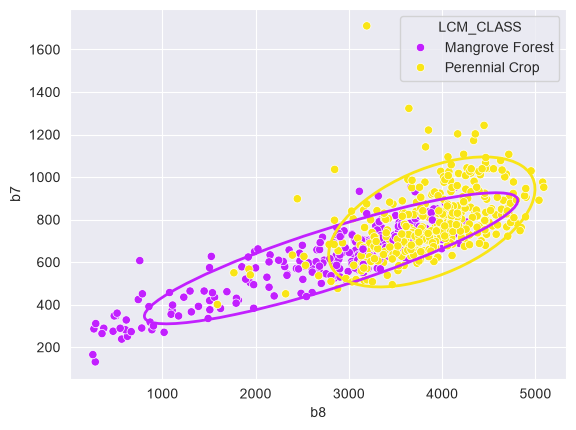

In [14]:
plot.scatterplot_bands(
    data=df_bands,
    band_x='b8',
    band_y='b7',
    category_column='LCM_CLASS',
    n_std=2,
    cats_compared=vegetation_classes
)

In [8]:
df_stats = validate.agg_per_class(
    data=df_bands,
    category_column='LCM_CLASS',
    band_names=band_names,
    cats_compared=vegetation_classes,
)

df_stats.head()

,LCM_CLASS,b1_mean,b1_std,b2_mean,b2_std,b3_mean,b3_std,b4_mean,b4_std,b5_mean,b5_std,b6_mean,b6_std,b7_mean,b7_std,b8_mean,b8_std
0,Mangrove Forest,123.018657,42.059478,226.776119,45.18429,342.164179,46.947607,352.160448,59.835546,304.212687,47.880191,193.973881,45.035101,618.033582,154.081727,2808.929104,1000.820962
1,Perennial Crop,128.517520,50.807497,227.900270,58.51166,399.113208,80.330117,409.137466,99.104913,357.369272,99.365996,219.552561,98.824766,789.000000,152.866432,3888.865229,553.052276


In [9]:
df_separability = validate.get_separability(
    df_stats=df_stats,
    category_column='LCM_CLASS',
    category_a='Mangrove Forest',
    category_b='Perennial Crop',
    band_names=band_names
)

df_separability.head()

,band,m_statistic,jm_distance
0,b1,0.059212,0.145295
1,b2,0.010841,0.181334
2,b3,0.447439,0.547783
3,b4,0.358480,0.478676
4,b5,0.361005,0.575350


<Axes: xlabel='band', ylabel='jm_distance'>

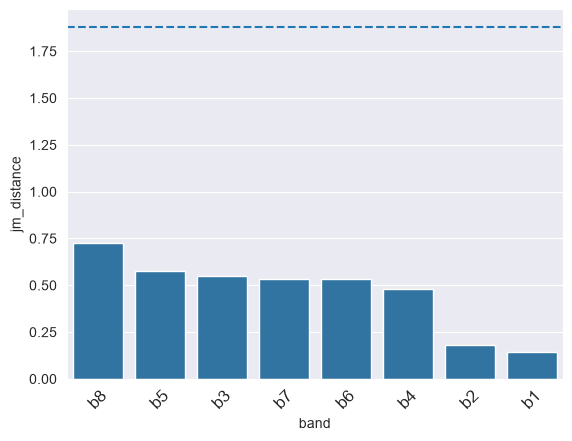

In [10]:
plot.separability_2class(
    data_separability=df_separability,
    separability_column='jm_distance',
    band_column='band',
    threshold=1.88
)